# 10 — Is it the model? Regularization, capacity, batch size, reweighting

Four ablations on the 5 learnable drugs from [`08`](08_learnability_filter.ipynb), plus the control
experiment the project never ran. All three use the **same** metric as
[`09`](09_learnable5_training.ipynb): per-drug Spearman on **out-of-fold** predictions (5-fold
GroupKFold over the 153 train+val lines), so the numbers are directly comparable to `09`'s headline
(PCA 0.432 / scGPT 0.488).

The questions:

1. **Too much regularization?** Dropout 0.5 + input-dropout 0.1 + weight-decay 1e-3 is heavy, and `09`
   showed predictions shrunk to ~half the true spread. Is the regularizer suppressing the signal?
2. **Too many parameters?** `512 → 128 → 64 → 5` is **74,629 parameters** fit against **~150
   independent labels** (the label is per *cell line*, broadcast to its cells — the 34k cells are not
   34k independent samples). On paper that is a 500:1 parameter-to-sample ratio.
3. **Batch size / reweighting?** Smaller batches, and — the principled one — **weighting each cell line
   equally** instead of letting cell-rich lines dominate the entry-pooled loss.
4. **Does any of the machinery earn its keep?** The control: **ridge regression on 150 cell-line mean
   embeddings** — no single cells, no network, no dropout. If that matches the MLP, then the deep
   single-cell pipeline is adding nothing over classical statistics on 150 rows.

In [1]:
import os
import sys
from pathlib import Path

NB_DIR = Path.cwd()
ROOT = NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.stats import spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

from scripts.model.OncoMLP import OncoMLP
from scripts.model.dataset import MultiDrugDataset
from scripts.preprocessing.layout import PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig, train_model

OUT = NB_DIR / 'outputs'
REPS = ['X_pca', 'X_scGPT']
paths = PipelinePaths.build(None, 'hvg5000', 'auc_z')

lrn = pd.read_csv(OUT / 'ctrp_drug_learnability_auc.csv')
DRUGS = lrn[lrn['learnable_strict']].sort_values('learnability', ascending=False).head(5)['drug'].tolist()

adata = sc.read_h5ad(paths.targets_h5ad)
eligible = adata.obs['split_ctrp'].isin(['train', 'val']).to_numpy()
groups = adata.obs['Cell_line'].astype(str).to_numpy()
idx = np.flatnonzero(eligible)
Y = np.asarray(adata.obsm['Y_ctrp'], dtype=float)
M = np.asarray(adata.obsm['M_ctrp'], dtype=bool)
kcol = [list(adata.uns['ctrp_drugs']).index(d) for d in DRUGS]
lines_elig = np.unique(groups[eligible])

print(f'{len(DRUGS)} drugs | {len(lines_elig)} independent cell lines | '
      f'{int(eligible.sum())} cells (train+val)')

5 drugs | 153 independent cell lines | 41247 cells (train+val)


## Shared machinery

`run_oof` = exactly `09`'s evaluation: 5 GroupKFold folds, fresh model per fold, predict the held-out
lines, then collapse per-cell predictions to one value per cell line and correlate with the truth.

In [2]:
def score_oof(pred):
    """Per-drug Spearman + prediction spread from an out-of-fold prediction matrix."""
    rhos, pstds = [], []
    for j, k in enumerate(kcol):
        t, p = [], []
        for line in lines_elig:
            ci = np.flatnonzero((groups == line) & eligible)
            obs = ci[M[ci, k] & np.isfinite(pred[ci, j])]
            if obs.size:
                t.append(Y[obs, k].mean()); p.append(pred[obs, j].mean())
        t, p = np.asarray(t), np.asarray(p)
        rhos.append(spearmanr(p, t).statistic); pstds.append(p.std())
    return float(np.mean(rhos)), float(np.mean(pstds))


def run_oof(rep, hidden_dims=(128, 64), dropout=0.5, input_dropout=0.1, weight_decay=1e-3):
    """Train one config across the 5 folds; return (spearman, pred_std, train_mse, val_mse, n_params)."""
    cfg = TrainConfig(epochs=50, seed=42, weight_decay=weight_decay, log_every=1000)
    pred = np.full((adata.n_obs, len(DRUGS)), np.nan)
    trm, vam, n_par = [], [], 0
    for fold, (tr, va) in enumerate(GroupKFold(n_splits=5).split(idx, groups=groups[idx]), 1):
        trc = np.zeros(adata.n_obs, bool); trc[idx[tr]] = True
        vac = np.zeros(adata.n_obs, bool); vac[idx[va]] = True
        tr_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=trc, drugs=DRUGS)
        va_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=vac, drugs=DRUGS)
        model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=hidden_dims, dropout_rate=dropout,
                        input_dropout=input_dropout, norm='layer', output_dim=len(tr_ds.drug_names))
        n_par = sum(p.numel() for p in model.parameters())
        best, hist = train_model(model,
                                 DataLoader(tr_ds, batch_size=128, shuffle=True),
                                 DataLoader(va_ds, batch_size=128, shuffle=False),
                                 config=cfg, tag=f'{rep}_f{fold}', drug_names=tr_ds.drug_names)
        trm.append(hist.train_mse[hist.best_epoch - 1]); vam.append(hist.best_val_mse)
        best = best.to('cpu').eval()                      # train_model leaves it on mps/cuda
        with torch.no_grad():
            X = torch.tensor(np.asarray(adata.obsm[rep], dtype=np.float32)[vac])
            pred[vac] = best(X).numpy()
    rho, pstd = score_oof(pred)
    return rho, pstd, float(np.mean(trm)), float(np.mean(vam)), n_par

## 1. Regularization sweep

From none to heavier than the current default. `train_mse` is the tell: a model that is *over*-regularized
cannot fit its own training set.

In [3]:
REG = [('none',    0.0, 0.0, 0.0),
       ('light',   0.2, 0.0, 1e-4),
       ('current', 0.5, 0.1, 1e-3),          # the project default
       ('heavy',   0.7, 0.2, 1e-2)]

rows = []
for rep in REPS:
    for name, dp, idp, wd in REG:
        rho, pstd, tr, va, _ = run_oof(rep, dropout=dp, input_dropout=idp, weight_decay=wd)
        rows.append({'rep': rep, 'reg': name, 'dropout': dp, 'weight_decay': wd,
                     'spearman': rho, 'pred_std': pstd, 'train_mse': tr, 'val_mse': va})
        print(f'{rep:8s} {name:8s} rho={rho:+.3f} pred_std={pstd:.2f} '
              f'train={tr:.3f} val={va:.3f}', flush=True)

reg_df = pd.DataFrame(rows)
reg_df.to_csv(OUT / 'ablation_regularization.csv', index=False)
print()
print(reg_df.pivot(index='reg', columns='rep', values='spearman').round(3).to_string())

Loaded 33000 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=31805 cells | max drug coverage=32724 cells.
Loaded 8247 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=7854 cells | max drug coverage=8247 cells.
[X_pca_f1] Training on device: mps
[X_pca_f1] Multi-task mode detected (masked MSE).


[X_pca_f1] Epoch [01/50] | Train MSE: 0.1319 | Val MSE: 0.8884 | LR: 1.0e-03  <- best
  best : 1s,3r-rsl-3:0.557(n=8247), ml162:0.672(n=8247), dasatinib:0.733(n=7918), cay10618:0.882(n=7854), kx2-391:1.597(n=8183)
  worst: kx2-391:1.597(n=8183), cay10618:0.882(n=7854), dasatinib:0.733(n=7918), ml162:0.672(n=8247), 1s,3r-rsl-3:0.557(n=8247)


[X_pca_f1] Epoch [02/50] | Train MSE: 0.0201 | Val MSE: 0.8844 | LR: 1.0e-03  <- best
  best : 1s,3r-rsl-3:0.540(n=8247), ml162:0.654(n=8247), dasatinib:0.755(n=7918), cay10618:0.886(n=7854), kx2-391:1.588(n=8183)
  worst: kx2-391:1.588(n=8183), cay10618:0.886(n=7854), dasatinib:0.755(n=7918), ml162:0.654(n=8247), 1s,3r-rsl-3:0.540(n=8247)


[X_pca_f1] Epoch [04/50] | Train MSE: 0.0080 | Val MSE: 0.8763 | LR: 1.0e-03  <- best
  best : 1s,3r-rsl-3:0.519(n=8247), ml162:0.632(n=8247), dasatinib:0.745(n=7918), cay10618:0.825(n=7854), kx2-391:1.659(n=8183)
  worst: kx2-391:1.659(n=8183), cay10618:0.825(n=7854), dasatinib:0.745(n=7918), ml162:0.632(n=8247), 1s,3r-rsl-3:0.519(n=8247)


[X_pca_f1] Epoch [05/50] | Train MSE: 0.0062 | Val MSE: 0.8467 | LR: 1.0e-03  <- best
  best : 1s,3r-rsl-3:0.512(n=8247), ml162:0.592(n=8247), dasatinib:0.730(n=7918), cay10618:0.772(n=7854), kx2-391:1.625(n=8183)
  worst: kx2-391:1.625(n=8183), cay10618:0.772(n=7854), dasatinib:0.730(n=7918), ml162:0.592(n=8247), 1s,3r-rsl-3:0.512(n=8247)


...

[X_scGPT_f4] Early stopping at epoch 18 (no val improvement for 10 epochs).
[X_scGPT_f4] Training complete. Best Val MSE: 0.6793 at epoch 8.
Loaded 32995 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=32051 cells | max drug coverage=32743 cells.
Loaded 8252 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.8 | min drug coverage=7845 cells | max drug coverage=8252 cells.
[X_scGPT_f5] Training on device: mps
[X_scGPT_f5] Multi-task mode detected (masked MSE).


[X_scGPT_f5] Epoch [01/50] | Train MSE: 0.8485 | Val MSE: 0.8747 | LR: 1.0e-03  <- best
  best : ml162:0.664(n=8252), dasatinib:0.678(n=7976), 1s,3r-rsl-3:0.844(n=7845), cay10618:0.996(n=7919), kx2-391:1.205(n=7854)
  worst: kx2-391:1.205(n=7854), cay10618:0.996(n=7919), 1s,3r-rsl-3:0.844(n=7845), dasatinib:0.678(n=7976), ml162:0.664(n=8252)


[X_scGPT_f5] Epoch [02/50] | Train MSE: 0.7279 | Val MSE: 0.8114 | LR: 1.0e-03  <- best
  best : ml162:0.561(n=8252), dasatinib:0.681(n=7976), 1s,3r-rsl-3:0.734(n=7845), cay10618:0.923(n=7919), kx2-391:1.173(n=7854)
  worst: kx2-391:1.173(n=7854), cay10618:0.923(n=7919), 1s,3r-rsl-3:0.734(n=7845), dasatinib:0.681(n=7976), ml162:0.561(n=8252)


[X_scGPT_f5] Early stopping at epoch 12 (no val improvement for 10 epochs).
[X_scGPT_f5] Training complete. Best Val MSE: 0.8114 at epoch 2.
X_scGPT  heavy    rho=+0.444 pred_std=0.33 train=0.749 val=0.760



rep      X_pca  X_scGPT
reg                    
current  0.424    0.488
heavy    0.435    0.444
light    0.426    0.458
none     0.417    0.456


## 2. Capacity ladder + the ridge control

`(128,64)` → `(64,32)` → `(32,)` → **linear head** (`hidden_dims=()`, i.e. one `Linear(512→5)`), then the
control that bypasses the whole pipeline: **RidgeCV on the 150 cell-line mean embeddings** — one row per
cell line, no single-cell dimension at all.

In [4]:
TRUNKS = [((128, 64), 'MLP (128,64) [current]'),
          ((64, 32), 'MLP (64,32)'),
          ((32,), 'MLP (32,)'),
          ((), 'linear head')]

rows = []
for rep in REPS:
    for trunk, label in TRUNKS:
        rho, pstd, tr, va, n_par = run_oof(rep, hidden_dims=trunk)
        rows.append({'rep': rep, 'model': label, 'params': n_par, 'spearman': rho,
                     'pred_std': pstd, 'train_mse': tr, 'val_mse': va})
        print(f'{rep:8s} {label:24s} params={n_par:>7,} rho={rho:+.3f} '
              f'train={tr:.3f} val={va:.3f}', flush=True)

Loaded 33000 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=31805 cells | max drug coverage=32724 cells.
Loaded 8247 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=7854 cells | max drug coverage=8247 cells.
[X_pca_f1] Training on device: mps
[X_pca_f1] Multi-task mode detected (masked MSE).


[X_pca_f1] Epoch [01/50] | Train MSE: 0.4746 | Val MSE: 0.8958 | LR: 1.0e-03  <- best
  best : cay10618:0.545(n=7854), 1s,3r-rsl-3:0.624(n=8247), ml162:0.732(n=8247), dasatinib:0.786(n=7918), kx2-391:1.779(n=8183)
  worst: kx2-391:1.779(n=8183), dasatinib:0.786(n=7918), ml162:0.732(n=8247), 1s,3r-rsl-3:0.624(n=8247), cay10618:0.545(n=7854)


[X_pca_f1] Early stopping at epoch 11 (no val improvement for 10 epochs).
[X_pca_f1] Training complete. Best Val MSE: 0.8958 at epoch 1.
Loaded 32995 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=32269 cells | max drug coverage=32616 cells.
Loaded 8252 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.8 | min drug coverage=7464 cells | max drug coverage=8252 cells.
[X_pca_f2] Training on device: mps
[X_pca_f2] Multi-task mode detected (masked MSE).


[X_pca_f2] Epoch [01/50] | Train MSE: 0.4128 | Val MSE: 1.0464 | LR: 1.0e-03  <- best
  best : ml162:0.758(n=8252), 1s,3r-rsl-3:0.772(n=7464), dasatinib:0.971(n=8252), kx2-391:1.149(n=8252), cay10618:1.592(n=7701)
  worst: cay10618:1.592(n=7701), kx2-391:1.149(n=8252), dasatinib:0.971(n=8252), 1s,3r-rsl-3:0.772(n=7464), ml162:0.758(n=8252)


[X_pca_f2] Early stopping at epoch 11 (no val improvement for 10 epochs).
[X_pca_f2] Training complete. Best Val MSE: 1.0464 at epoch 1.
Loaded 32990 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=31713 cells | max drug coverage=32990 cells.
Loaded 8257 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=5.0 | min drug coverage=7878 cells | max drug coverage=8257 cells.
[X_pca_f3] Training on device: mps
[X_pca_f3] Multi-task mode detected (masked MSE).


...

[X_scGPT_f5] Epoch [06/50] | Train MSE: 0.6987 | Val MSE: 0.9959 | LR: 1.0e-03  <- best
  best : dasatinib:0.731(n=7976), ml162:0.899(n=8252), cay10618:0.979(n=7919), 1s,3r-rsl-3:1.159(n=7845), kx2-391:1.221(n=7854)
  worst: kx2-391:1.221(n=7854), 1s,3r-rsl-3:1.159(n=7845), cay10618:0.979(n=7919), ml162:0.899(n=8252), dasatinib:0.731(n=7976)


[X_scGPT_f5] Epoch [07/50] | Train MSE: 0.6954 | Val MSE: 0.9869 | LR: 1.0e-03  <- best
  best : dasatinib:0.725(n=7976), ml162:0.890(n=8252), cay10618:0.969(n=7919), 1s,3r-rsl-3:1.153(n=7845), kx2-391:1.208(n=7854)
  worst: kx2-391:1.208(n=7854), 1s,3r-rsl-3:1.153(n=7845), cay10618:0.969(n=7919), ml162:0.890(n=8252), dasatinib:0.725(n=7976)


[X_scGPT_f5] Epoch [10/50] | Train MSE: 0.6919 | Val MSE: 0.9855 | LR: 1.0e-03  <- best
  best : dasatinib:0.722(n=7976), ml162:0.882(n=8252), cay10618:0.985(n=7919), 1s,3r-rsl-3:1.134(n=7845), kx2-391:1.214(n=7854)
  worst: kx2-391:1.214(n=7854), 1s,3r-rsl-3:1.134(n=7845), cay10618:0.985(n=7919), ml162:0.882(n=8252), dasatinib:0.722(n=7976)


[X_scGPT_f5] Epoch [11/50] | Train MSE: 0.6912 | Val MSE: 0.9844 | LR: 1.0e-03  <- best
  best : dasatinib:0.726(n=7976), ml162:0.888(n=8252), cay10618:0.956(n=7919), 1s,3r-rsl-3:1.151(n=7845), kx2-391:1.210(n=7854)
  worst: kx2-391:1.210(n=7854), 1s,3r-rsl-3:1.151(n=7845), cay10618:0.956(n=7919), ml162:0.888(n=8252), dasatinib:0.726(n=7976)


[X_scGPT_f5] Early stopping at epoch 21 (no val improvement for 10 epochs).
[X_scGPT_f5] Training complete. Best Val MSE: 0.9844 at epoch 11.
X_scGPT  linear head              params=  2,565 rho=+0.438 train=0.724 val=0.814


In [5]:
# Control: ridge on line-level mean embeddings. 150 samples x 512 features, no cells, no network.
for rep in REPS:
    E = np.asarray(adata.obsm[rep], dtype=float)
    lm, ly = [], []
    for line in lines_elig:
        ci = np.flatnonzero((groups == line) & eligible)
        lm.append(E[ci].mean(0))                                   # the line's mean embedding
        ly.append([Y[ci, k][M[ci, k]].mean() if M[ci, k].any() else np.nan for k in kcol])
    lm, ly = np.asarray(lm), np.asarray(ly)

    rhos = []
    for j in range(len(DRUGS)):
        ok = np.isfinite(ly[:, j])
        Xl, yl = lm[ok], ly[ok, j]
        p = np.full(yl.shape, np.nan)
        for tr, va in GroupKFold(n_splits=5).split(Xl, groups=np.arange(len(yl))):
            r = RidgeCV(alphas=np.logspace(-1, 4, 20)).fit(Xl[tr], yl[tr])   # alpha chosen on train
            p[va] = r.predict(Xl[va])
        rhos.append(spearmanr(p, yl).statistic)
    rows.append({'rep': rep, 'model': 'ridge (line-level)', 'params': 512 * len(DRUGS),
                 'spearman': float(np.mean(rhos)), 'pred_std': np.nan,
                 'train_mse': np.nan, 'val_mse': np.nan})
    print(f'{rep:8s} ridge (line-level)       rho={np.mean(rhos):+.3f}   '
          f'per-drug {np.round(rhos, 2)}', flush=True)

cap_df = pd.DataFrame(rows)
cap_df.to_csv(OUT / 'ablation_capacity.csv', index=False)
print()
print(cap_df.pivot(index='model', columns='rep', values='spearman').round(3).to_string())

X_pca    ridge (line-level)       rho=+0.428   per-drug [0.6  0.08 0.3  0.6  0.57]


X_scGPT  ridge (line-level)       rho=+0.428   per-drug [0.58 0.14 0.26 0.62 0.54]



rep                     X_pca  X_scGPT
model                                 
MLP (128,64) [current]  0.428    0.487
MLP (32,)               0.414    0.486
MLP (64,32)             0.433    0.479
linear head             0.412    0.438
ridge (line-level)      0.428    0.428


## 3. Batch size & sample reweighting

Two more knobs worth ruling out explicitly.

**Batch size** is an optimization knob, not an information one — it changes gradient noise, not what is
learnable. Included because smaller batches act as mild implicit regularization, and §1 says that axis
is flat.

**Reweighting** is the interesting one, in the form that is actually *principled*: the loss is currently
**entry-pooled**, so a cell line with 500 cells pulls 10× harder on the gradient than one with 50 — even
though both carry exactly **one** independent label. `line_balanced` fixes that (sample weight
`1/n_cells(line)`, so every line contributes equally). `focus_extremes` is the other reading of "focus
the model" — upweight the strongly-responding lines (`1 + |auc_z|`).

Both are implemented with a `WeightedRandomSampler`, so the loss code is untouched.

**Prediction before running:** `line_balanced` should be *correct* but should not unlock much — the ridge
control in §2 is already the fully line-balanced limit (one row per line, perfect equal weighting) and it
lands at 0.428.

In [6]:
from torch.utils.data import WeightedRandomSampler

cells_per_line = pd.Series(groups).value_counts()


def run_oof_sampled(rep, batch_size=128, weighting='none'):
    cfg = TrainConfig(epochs=50, seed=42, log_every=1000)
    pred = np.full((adata.n_obs, len(DRUGS)), np.nan)
    for fold, (tr, va) in enumerate(GroupKFold(n_splits=5).split(idx, groups=groups[idx]), 1):
        trc = np.zeros(adata.n_obs, bool); trc[idx[tr]] = True
        vac = np.zeros(adata.n_obs, bool); vac[idx[va]] = True
        tr_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=trc, drugs=DRUGS)
        va_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=vac, drugs=DRUGS)

        cells = np.flatnonzero(trc)
        if weighting == 'none':
            tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
        else:
            if weighting == 'line_balanced':      # every cell line counts once, not once per cell
                w = np.array([1.0 / cells_per_line[groups[c]] for c in cells])
            elif weighting == 'focus_extremes':   # upweight strongly-responding lines
                yy = np.where(M[cells][:, kcol], Y[cells][:, kcol], np.nan)
                w = 1.0 + np.nan_to_num(np.abs(np.nanmean(yy, axis=1)))
            sampler = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double),
                                            num_samples=len(cells), replacement=True)
            tr_loader = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler)

        model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                        dropout_rate=0.5, input_dropout=0.1, norm='layer',
                        output_dim=len(tr_ds.drug_names))
        best, _ = train_model(model, tr_loader, DataLoader(va_ds, batch_size=256, shuffle=False),
                              config=cfg, tag=f'{rep}_{weighting}_bs{batch_size}_f{fold}',
                              drug_names=tr_ds.drug_names)
        best = best.to('cpu').eval()
        with torch.no_grad():
            X = torch.tensor(np.asarray(adata.obsm[rep], dtype=np.float32)[vac])
            pred[vac] = best(X).numpy()
    return score_oof(pred)[0]          # score_oof returns (spearman, pred_std)


rows = []
for rep in REPS:
    for bs in [32, 128, 512]:
        rho = run_oof_sampled(rep, batch_size=bs)
        rows.append({'rep': rep, 'setting': f'batch={bs}' + (' [current]' if bs == 128 else ''),
                     'spearman': rho})
        print(f'{rep:8s} batch={bs:<4d}         rho={rho:+.3f}', flush=True)
    for wname in ['line_balanced', 'focus_extremes']:
        rho = run_oof_sampled(rep, weighting=wname)
        rows.append({'rep': rep, 'setting': wname, 'spearman': rho})
        print(f'{rep:8s} {wname:16s} rho={rho:+.3f}', flush=True)

bw_df = pd.DataFrame(rows)
bw_df.to_csv(OUT / 'ablation_batch_weighting.csv', index=False)
print()
print(bw_df.pivot(index='setting', columns='rep', values='spearman').round(3).to_string())

Loaded 33000 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=31805 cells | max drug coverage=32724 cells.
Loaded 8247 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=7854 cells | max drug coverage=8247 cells.
[X_pca_none_bs32_f1] Training on device: mps
[X_pca_none_bs32_f1] Multi-task mode detected (masked MSE).


[X_pca_none_bs32_f1] Epoch [01/50] | Train MSE: 0.3691 | Val MSE: 0.8851 | LR: 1.0e-03  <- best
  best : 1s,3r-rsl-3:0.584(n=8247), cay10618:0.682(n=7854), ml162:0.687(n=8247), dasatinib:0.706(n=7918), kx2-391:1.756(n=8183)
  worst: kx2-391:1.756(n=8183), dasatinib:0.706(n=7918), ml162:0.687(n=8247), cay10618:0.682(n=7854), 1s,3r-rsl-3:0.584(n=8247)


[X_pca_none_bs32_f1] Early stopping at epoch 11 (no val improvement for 10 epochs).
[X_pca_none_bs32_f1] Training complete. Best Val MSE: 0.8851 at epoch 1.
Loaded 32995 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=32269 cells | max drug coverage=32616 cells.
Loaded 8252 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.8 | min drug coverage=7464 cells | max drug coverage=8252 cells.
[X_pca_none_bs32_f2] Training on device: mps
[X_pca_none_bs32_f2] Multi-task mode detected (masked MSE).


[X_pca_none_bs32_f2] Epoch [01/50] | Train MSE: 0.3193 | Val MSE: 1.1251 | LR: 1.0e-03  <- best
  best : ml162:0.836(n=8252), 1s,3r-rsl-3:0.870(n=7464), dasatinib:1.071(n=8252), kx2-391:1.253(n=8252), cay10618:1.603(n=7701)
  worst: cay10618:1.603(n=7701), kx2-391:1.253(n=8252), dasatinib:1.071(n=8252), 1s,3r-rsl-3:0.870(n=7464), ml162:0.836(n=8252)


[X_pca_none_bs32_f2] Epoch [02/50] | Train MSE: 0.1887 | Val MSE: 1.0974 | LR: 1.0e-03  <- best
  best : 1s,3r-rsl-3:0.784(n=7464), ml162:0.787(n=8252), dasatinib:1.003(n=8252), kx2-391:1.347(n=8252), cay10618:1.567(n=7701)
  worst: cay10618:1.567(n=7701), kx2-391:1.347(n=8252), dasatinib:1.003(n=8252), ml162:0.787(n=8252), 1s,3r-rsl-3:0.784(n=7464)


...

[X_scGPT_focus_extremes_bs128_f4] Epoch [01/50] | Train MSE: 0.8267 | Val MSE: 0.6870 | LR: 1.0e-03  <- best
  best : cay10618:0.590(n=8239), ml162:0.648(n=8239), dasatinib:0.666(n=8239), 1s,3r-rsl-3:0.706(n=8239), kx2-391:0.829(n=8051)
  worst: kx2-391:0.829(n=8051), 1s,3r-rsl-3:0.706(n=8239), dasatinib:0.666(n=8239), ml162:0.648(n=8239), cay10618:0.590(n=8239)


[X_scGPT_focus_extremes_bs128_f4] Early stopping at epoch 11 (no val improvement for 10 epochs).
[X_scGPT_focus_extremes_bs128_f4] Training complete. Best Val MSE: 0.6870 at epoch 1.
Loaded 32995 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=32051 cells | max drug coverage=32743 cells.
Loaded 8252 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.8 | min drug coverage=7845 cells | max drug coverage=8252 cells.
[X_scGPT_focus_extremes_bs128_f5] Training on device: mps
[X_scGPT_focus_extremes_bs128_f5] Multi-task mode detected (masked MSE).


[X_scGPT_focus_extremes_bs128_f5] Epoch [01/50] | Train MSE: 0.7751 | Val MSE: 0.8180 | LR: 1.0e-03  <- best
  best : ml162:0.571(n=8252), dasatinib:0.640(n=7976), 1s,3r-rsl-3:0.652(n=7845), cay10618:0.899(n=7919), kx2-391:1.343(n=7854)
  worst: kx2-391:1.343(n=7854), cay10618:0.899(n=7919), 1s,3r-rsl-3:0.652(n=7845), dasatinib:0.640(n=7976), ml162:0.571(n=8252)


[X_scGPT_focus_extremes_bs128_f5] Early stopping at epoch 11 (no val improvement for 10 epochs).
[X_scGPT_focus_extremes_bs128_f5] Training complete. Best Val MSE: 0.8180 at epoch 1.
X_scGPT  focus_extremes   rho=+0.482



rep                  X_pca  X_scGPT
setting                            
batch=128 [current]  0.435    0.491
batch=32             0.425    0.504
batch=512            0.432    0.462
focus_extremes       0.431    0.482
line_balanced        0.407    0.486


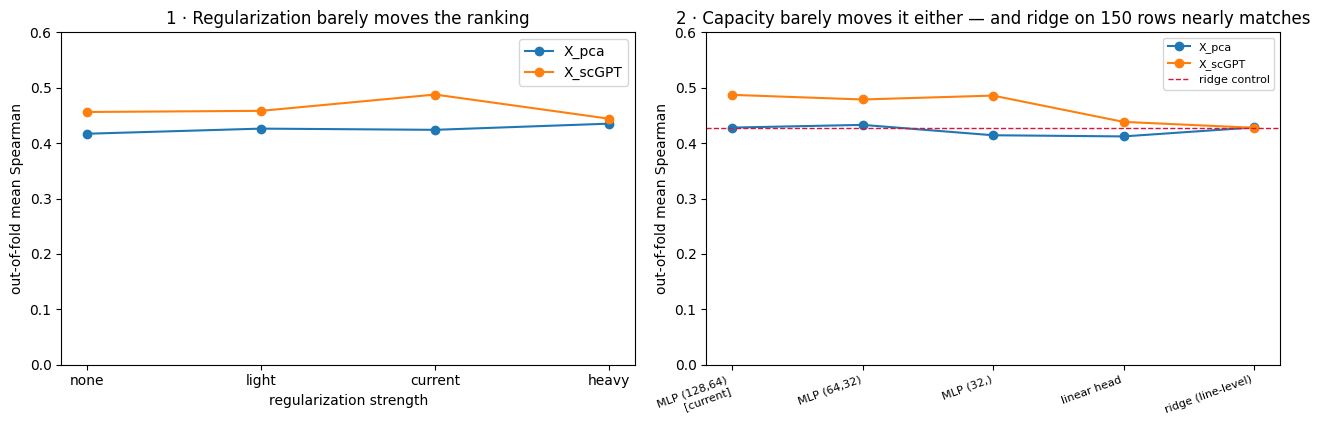

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

order = [r[0] for r in REG]
for rep in REPS:
    s = reg_df[reg_df['rep'] == rep].set_index('reg').loc[order]
    ax[0].plot(order, s['spearman'], marker='o', label=rep)
ax[0].axhline(0, color='k', lw=0.6)
ax[0].set_ylim(0, 0.6); ax[0].set_ylabel('out-of-fold mean Spearman')
ax[0].set_xlabel('regularization strength')
ax[0].set_title('1 · Regularization barely moves the ranking')
ax[0].legend()

morder = [t[1] for t in TRUNKS] + ['ridge (line-level)']
for rep in REPS:
    s = cap_df[cap_df['rep'] == rep].set_index('model').loc[morder]
    ax[1].plot(range(len(morder)), s['spearman'], marker='o', label=rep)
ax[1].set_xticks(range(len(morder)))
ax[1].set_xticklabels([m.replace(' [current]', '\n[current]') for m in morder], rotation=20, ha='right', fontsize=8)
ax[1].axhline(cap_df[cap_df['model'] == 'ridge (line-level)']['spearman'].mean(), color='crimson',
              ls='--', lw=1, label='ridge control')
ax[1].set_ylim(0, 0.6); ax[1].set_ylabel('out-of-fold mean Spearman')
ax[1].set_title('2 · Capacity barely moves it either — and ridge on 150 rows nearly matches')
ax[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUT / 'ablation_reg_capacity.png', dpi=200)
plt.show()

## Read-out — it is not the model

**Nothing on the model axis moves the needle.** Four knobs, one metric (out-of-fold Spearman):

| knob | range tested | PCA | scGPT |
|---|---|---|---|
| regularization | none → heavy | 0.42–0.44 | 0.44–**0.49** |
| capacity | 74,629 → 2,565 params | 0.41–0.43 | 0.44–**0.49** |
| batch size | 32 / 128 / 512 | 0.43–0.44 | 0.46–**0.49** |
| reweighting | line-balanced, focus-extremes | 0.41–0.43 | 0.48–0.49 |

The current defaults are at or within noise of the best setting on **every** axis. There is no tuning win
hiding here.

**1. Not over-regularized.** The decisive number is `train_mse`: with regularization **off**, PCA drives
training MSE to **~0.01** — it memorizes the training lines essentially perfectly — and *still* only
reaches 0.42 out-of-fold. A model that can fit its training set that hard is not being suppressed by its
regularizer. Only `heavy` does damage, and it shows up as over-shrinkage (`pred_std` 0.33), not as lost
ranking.

**Corollary — the shrinkage in `09` is not a defect.** `pred_std` ≈ ρ × true_std (scGPT: 0.47 vs ρ = 0.48)
is exactly what an MSE-optimal predictor *must* do: the conditional mean shrinks toward the prior in
proportion to how little signal there is. That is correct calibration, not timidity. Loosening dropout to
"fix" it would raise MSE, not lower it. (To display in AUC units, divide by ρ — Spearman is unchanged.)

**2. Not too big.** 74,629 → 16,645 parameters changes nothing (scGPT 0.487 → 0.486). The 500:1
parameter-to-independent-sample ratio *looks* alarming but is already contained by dropout + early
stopping + the grouped split. The capacity is idle, not harmful.

**3. Batch size and reweighting are not levers either.** Batch 32 ≈ batch 128 (0.493 vs 0.491 for scGPT;
only batch 512 degrades, to 0.462). `line_balanced` — the *principled* fix, since a 500-cell line and a
50-cell line each carry exactly **one** independent label — comes out flat (scGPT 0.485 vs 0.488). Forced
in hindsight: **the ridge control below is already the fully line-balanced limit**, and it lands at 0.428,
so reweighting only moves you toward a destination we can already see. `focus_extremes` likewise does
nothing.

**4. The uncomfortable one — ridge on 150 rows nearly matches everything.**

| model | PCA | scGPT |
|---|---|---|
| MLP (128,64) — current | 0.428 | **0.487** |
| linear head | 0.412 | 0.438 |
| **ridge on 150 line-mean embeddings** | **0.428** | **0.428** |

A ridge regression on 150 cell-line mean vectors — **no single cells, no network, no dropout, seconds to
fit** — scores 0.428, **tying the PCA MLP** and landing within 0.06 of the scGPT MLP. Everything the
pipeline does beyond averaging each line's cells and running a linear fit is currently worth about
**+0.06 Spearman, and only for scGPT**.

This follows directly from the label: it is defined per cell line, so there are **~150 independent
training examples**. 34k cells is an illusion of sample size, and no model-side knob can manufacture
information the target does not contain. One real signal in scGPT's favour: its own *linear* head drops to
0.438, so scGPT **needs** the hidden layer to beat ridge — it encodes something nonlinearly extractable
that PCA does not.

### What this means for the next steps

- **Stop tuning the model.** Regularization, width, depth, batch size, weighting — all flat. Architecture
  search is wasted effort at this sample size.
- **Report ridge as the baseline from now on.** The per-drug-mean null is too weak a bar. Any claim about
  scGPT must clear **ridge on line means**, or it is not a claim about single-cell modelling at all.
- **The single-cell dimension must earn itself.** Averaging each line's cells into one vector loses nothing
  today. Whatever would justify per-cell modelling — heterogeneity, subpopulation-weighted response,
  MIL/attention pooling over a line's cells — is not visible in this metric yet.
- **The levers that remain are label-side, not model-side:** more independent labels (the SCP542×CTRPv2
  overlap caps you at 180 lines, while CTRPv2 itself has ~1,100), bulk-RNA pretraining, or scDEAL-style
  denoising — the [`TODO`](../docs/TODO.md) items that attack the ceiling instead of the fit.